In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None

display(HTML("<style>.container { width:100% !important; }</style>"))
plt.rcParams['figure.figsize'] = (24, 8)
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'
LOOKBACK = 21
HOLD_DAYS = 13


In [2]:
# 2. Data Loading
def load_all_data():
    all_data = []
    files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
    random.seed(42)
    random.shuffle(files)
    
    for file_path in files:
        if len(all_data) >= 100: # 100 stocks
            break
        symbol = os.path.basename(file_path).replace('.csv', '')
        try:
            df = pd.read_csv(file_path)
            df = df.dropna(subset=['Close'])
            
            if len(df) > 0:
                latest_price = df['Close'].iloc[-1]
                if latest_price < 90 or latest_price > 600:
                    continue
                    
            df['Date'] = pd.to_datetime(df['Date'])
            df = df.sort_values('Date').reset_index(drop=True)
            df['Symbol'] = symbol
            all_data.append(df)
        except Exception as e:
            pass
            
    return pd.concat(all_data, ignore_index=True)

data = load_all_data()


In [3]:
# 3. Calculate Strategy & MAE/MFE
def enrich_and_profile(df):
    df = df.copy()
    
    # Base Features
    df['Fwd_Ret'] = df['Close'].shift(-HOLD_DAYS) / df['Close'] - 1
    
    change = abs(df['Close'] - df['Close'].shift(LOOKBACK))
    volatility = df['Close'].diff().abs().rolling(LOOKBACK).sum()
    df['ER'] = change / volatility
    
    df['CumRet'] = (df['Close'] - df['Close'].shift(LOOKBACK)) / df['Close'].shift(LOOKBACK)
    
    weights = np.arange(1, LOOKBACK + 1)
    wma = df['Close'].rolling(LOOKBACK).apply(lambda x: np.dot(x, weights) / weights.sum(), raw=True)
    df['WMA_Ratio'] = df['Close'] / wma
    
    # Calculate MAE and MFE using rolling window for the next HOLD_DAYS
    # Shift(-1) because the trade starts the day AFTER the signal
    df['Min_Low_Future'] = df['Low'].shift(-1).rolling(window=HOLD_DAYS).min().shift(-(HOLD_DAYS - 1))
    df['Max_High_Future'] = df['High'].shift(-1).rolling(window=HOLD_DAYS).max().shift(-(HOLD_DAYS - 1))
    
    # Calculate Percentage Excursions relative to the entry closing price
    df['MAE'] = (df['Min_Low_Future'] - df['Close']) / df['Close']
    df['MFE'] = (df['Max_High_Future'] - df['Close']) / df['Close']
    
    return df

_data_list = []
for sym, grp in data.groupby('Symbol'):
    _data_list.append(enrich_and_profile(grp))
enriched_data = pd.concat(_data_list, ignore_index=True)

# 4. Filter for Champion Multi-Factor Trades (2023+)
test_data = enriched_data[enriched_data['Date'] >= '2023-01-01']

trades = test_data[
    (test_data['ER'] > 0.5) & 
    (test_data['CumRet'] > 0.1) & 
    (test_data['WMA_Ratio'] > 0.97) & 
    (test_data['WMA_Ratio'] < 1.10)
].dropna(subset=['Fwd_Ret', 'MAE', 'MFE'])

trades['Trade_Result'] = np.where(trades['Fwd_Ret'] > 0, 'Win', 'Loss')

print(f"Total Valid Trades: {len(trades)}")


Total Valid Trades: 2069


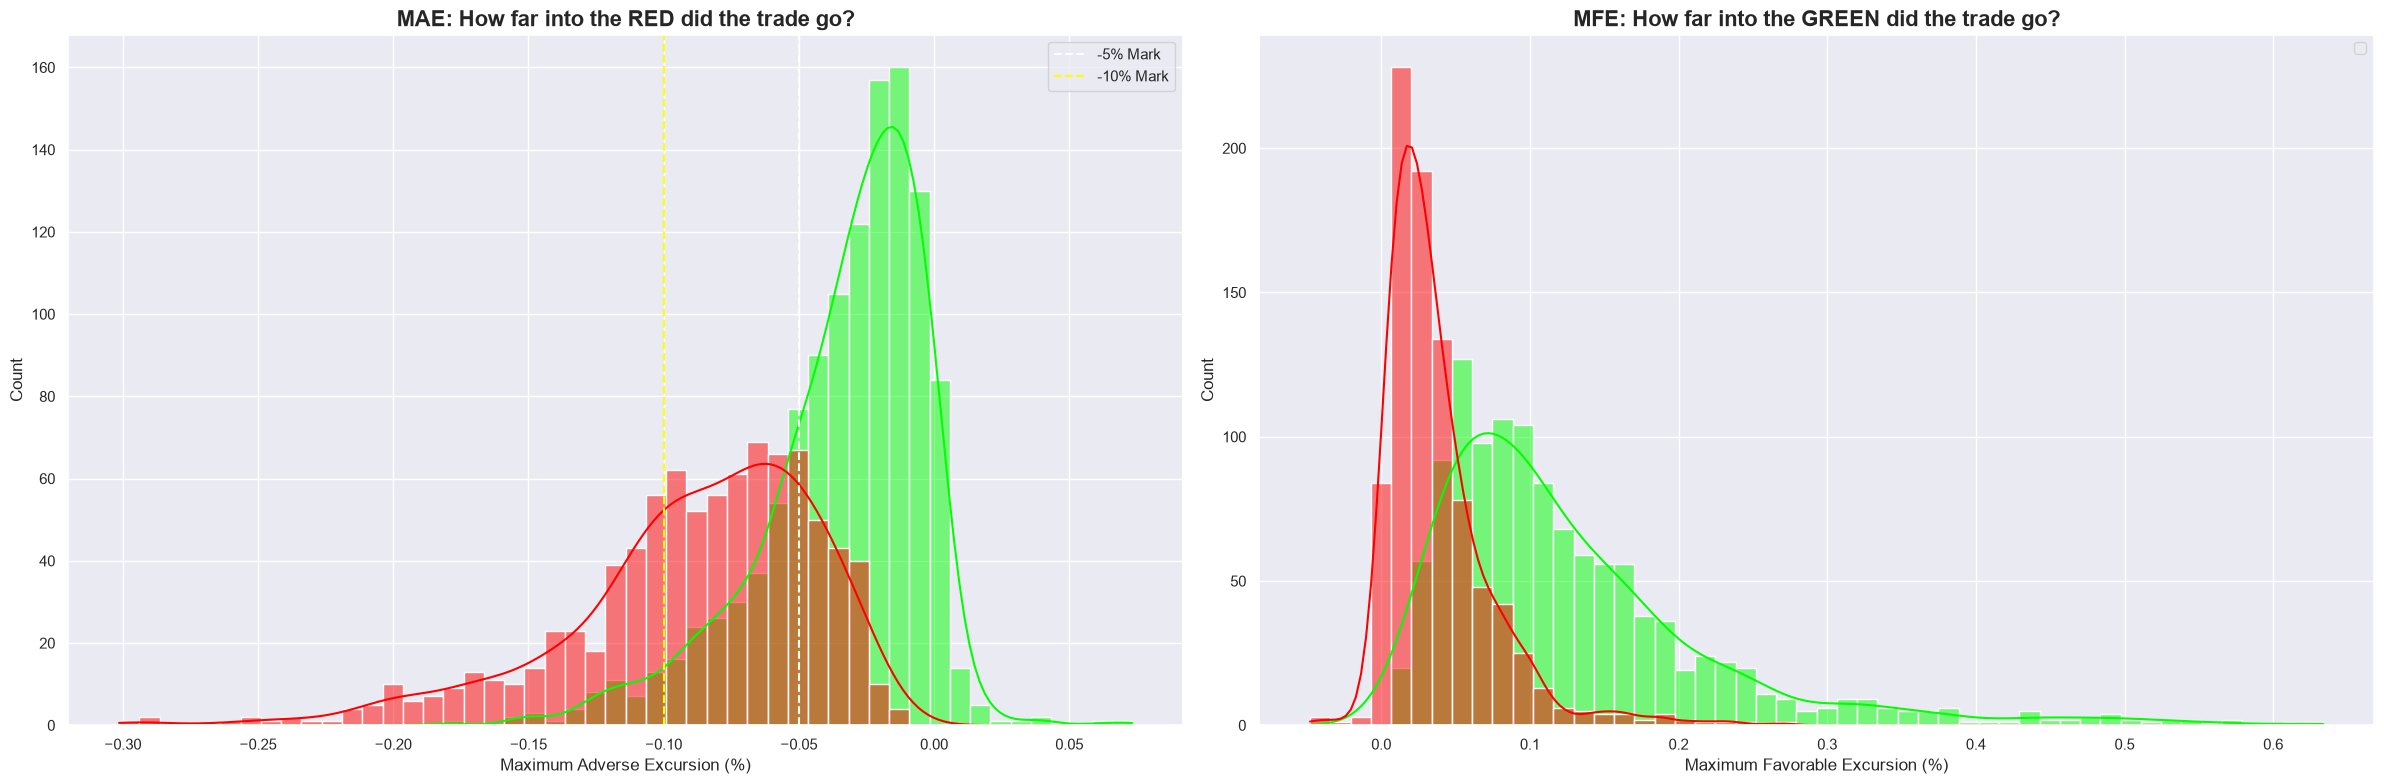

In [4]:
# 5. Visualize MAE and MFE Distributions
fig, axs = plt.subplots(1, 2, figsize=(24, 8))

# MAE (Maximum Adverse Excursion) - How low did it drop?
sns.histplot(data=trades, x='MAE', hue='Trade_Result', palette={'Win': 'lime', 'Loss': 'red'}, bins=50, kde=True, ax=axs[0])
axs[0].set_title('MAE: How far into the RED did the trade go?', fontsize=16, fontweight='bold')
axs[0].set_xlabel('Maximum Adverse Excursion (%)')
axs[0].axvline(x=-0.05, color='white', linestyle='--', label='-5% Mark')
axs[0].axvline(x=-0.10, color='yellow', linestyle='--', label='-10% Mark')
axs[0].legend()

# MFE (Maximum Favorable Excursion) - How high did it jump?
sns.histplot(data=trades, x='MFE', hue='Trade_Result', palette={'Win': 'lime', 'Loss': 'red'}, bins=50, kde=True, ax=axs[1])
axs[1].set_title('MFE: How far into the GREEN did the trade go?', fontsize=16, fontweight='bold')
axs[1].set_xlabel('Maximum Favorable Excursion (%)')
axs[1].legend()

plt.tight_layout()
plt.show()


In [5]:
# 6. Stop Loss Grid Search Simulator
stop_losses = [-0.03, -0.05, -0.08, -0.10, -0.15, -1.00] # -1.00 means No Stop Loss

sl_results = []

for sl in stop_losses:
    sim_trades = trades.copy()
    
    # If the MAE hit the stop loss, the return is capped at the Stop Loss
    # Otherwise, it gets the full 13-day Fwd_Ret
    sim_trades['Sim_Return'] = np.where(sim_trades['MAE'] <= sl, sl, sim_trades['Fwd_Ret'])
    sim_trades['Sim_Result'] = np.where(sim_trades['Sim_Return'] > 0, 'Win', 'Loss')
    
    win_rate = (sim_trades['Sim_Return'] > 0).mean() * 100
    avg_ret = sim_trades['Sim_Return'].mean() * 100
    total_profit = sim_trades['Sim_Return'].sum() * 100
    
    sl_results.append({
        'Stop_Loss': "No Stop" if sl == -1.0 else f"{int(sl * 100)}%",
        'Total_Trades': len(sim_trades),
        'Win_Rate': win_rate,
        'Avg_Trade_%': avg_ret,
        'Cumulative_System_Return_%': total_profit
    })

sl_df = pd.DataFrame(sl_results).sort_values(by='Cumulative_System_Return_%', ascending=False).reset_index(drop=True)

display(HTML("<h2>Stop-Loss Optimization Leaderboard</h2>"))
display(sl_df)


,Stop_Loss,Total_Trades,Win_Rate,Avg_Trade_%,Cumulative_System_Return_%
0,No Stop,2069,57.370710,2.514787,5203.094062
1,-15%,2069,57.177380,2.435743,5039.553120
2,-10%,2069,55.002417,2.021813,4183.132123
3,-8%,2069,52.392460,1.732720,3584.997029
4,-5%,2069,43.692605,1.357087,2807.813309
5,-3%,2069,31.367811,0.978576,2024.674109
